#  Analyse Exploratoire des Données (EDA)

## Contexte Business
Nous travaillons pour une entreprise SaaS avec 10 000 clients. L'objectif est de construire un système intelligent de rétention client capable d'anticiper les résiliations et d'évaluer 
l'impact financier.

## Nos 2 Problématiques

### Problématique 1 — Classification (obligatoire)
**Question :** Quel client va résilier son abonnement ?
**Variable cible :** `churn` (0 = reste, 1 = part)
**Intérêt business :** Prioriser les actions de rétention marketing

### Problématique 2 — Régression (points bonus)
**Question :** Combien d'argent risque-t-on de perdre ?
**Variable cible :** `revenue_at_risk = total_revenue × churn`
(approximation — la vraie formule utilise proba_churn une fois le modèle entraîné)
**Intérêt business :** Prioriser les clients à forte valeur financière

## Questions auxquelles l'EDA va répondre
1. Qui sont les clients qui churnent ?
2. Quels comportements annoncent un départ ?
3. Quelles variables sont les plus corrélées au churn ?
4. Quels segments sont les plus à risque financièrement ?
5. Y a-t-il des valeurs manquantes ou des outliers à traiter ?

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/customer_churn_business_dataset.csv')

## Premier regard sur les données

On affiche 10 lignes aléatoires du dataset.

Objectif : vérifier que les données sont bien chargées et 
comprendre la structure du tableau :

- Quelles colonnes existent ?
- Quels types de valeurs ?
- On remarque déjà que `complaint_type` a des valeurs `NaN`

In [19]:
df.sample(10)

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
94,CUST_00095,Female,53,Canada,Berlin,Individual,36,Mobile,Quarterly,5,...,30.230559,Service,2.0,0,0.61,0.29,16,Neutral,1,0
6671,CUST_06672,Female,61,Germany,Dhaka,Individual,14,Web,Monthly,12,...,16.233236,NaN,2.0,0,0.72,0.45,60,Satisfied,0,0
4032,CUST_04033,Male,43,Australia,Sydney,Enterprise,49,Web,Quarterly,12,...,15.410609,Technical,2.0,0,0.62,0.27,1,Satisfied,1,0
2494,CUST_02495,Male,39,Bangladesh,Dhaka,Individual,24,Referral,Quarterly,20,...,19.114282,Service,4.0,1,0.46,0.29,11,Satisfied,2,0
5554,CUST_05555,Female,71,Australia,Dhaka,Individual,24,Web,Monthly,0,...,25.633945,Technical,4.0,0,0.60,0.04,19,Satisfied,1,1
1018,CUST_01019,Female,55,India,Sydney,Individual,6,Referral,Yearly,6,...,29.853159,Billing,4.0,0,0.79,0.27,22,Neutral,0,0
555,CUST_00556,Female,24,USA,New York,SME,40,Web,Quarterly,26,...,22.098957,Billing,3.0,1,0.68,0.11,40,Neutral,2,0
8927,CUST_08928,Female,39,USA,Delhi,Individual,23,Web,Monthly,14,...,16.730625,Billing,3.0,0,0.90,0.49,18,Satisfied,0,0
296,CUST_00297,Female,56,Bangladesh,Toronto,Enterprise,58,Referral,Monthly,13,...,29.270422,Billing,4.0,0,0.45,0.18,-20,Neutral,3,0
6959,CUST_06960,Male,31,India,Dhaka,Individual,24,Mobile,Yearly,22,...,21.047935,Service,2.0,0,0.39,0.27,30,Unsatisfied,2,1


## Dimensions du dataset

On retourne un tuple (lignes, colonnes) :
- **10 000 lignes** = 10 000 clients
- **32 colonnes** = 32 variables par client

C'est un dataset de taille moyenne, suffisant pour entraîner 
des modèles de Machine Learning fiables.

In [20]:
print(f"Nombre de ligne : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

Nombre de ligne : 10000
Nombre de colonnes : 32


## Types des colonnes

On affiche le type de chaque colonne :
- **int64** = nombre entier (ex: age, churn)
- **float64** = nombre décimal (ex: monthly_fee, nps_score)
- **object** = texte / catégorie (ex: gender, country)

Cette étape est importante car les modèles de Machine Learning ne comprennent que des chiffres. Les colonnes "object" devront être converties en chiffres lors du preprocessing.

In [21]:
df.dtypes

customer_id                object
gender                     object
age                         int64
country                    object
city                       object
customer_segment           object
tenure_months               int64
signup_channel             object
contract_type              object
monthly_logins              int64
weekly_active_days          int64
avg_session_time          float64
features_used               int64
usage_growth_rate         float64
last_login_days_ago         int64
monthly_fee                 int64
total_revenue               int64
payment_method             object
payment_failures            int64
discount_applied           object
price_increase_last_3m     object
support_tickets             int64
avg_resolution_time       float64
complaint_type             object
csat_score                float64
escalations                 int64
email_open_rate           float64
marketing_click_rate      float64
nps_score                   int64
survey_respons

## Vérification des doublons

**Résultat : 0 doublon** 
Les données sont propres sur ce point, rien à supprimer.

In [22]:
df.duplicated().sum()

np.int64(0)

## Valeurs manquantes

`df.isnull().sum()` compte le nombre de valeurs vides par colonne.

**Résultat :**
- Toutes les colonnes : 0 valeur manquante 
- **complaint_type : 2045 valeurs manquantes** 

Pourquoi complaint_type a des manquants ?
Logique métier : un client qui n'a jamais fait de plainte n'a pas de type de plainte. Ce n'est pas une erreur,  c'est une information en soi.

**Décision :** On remplacera ces manquants par "No_Complaint" lors du preprocessing.

In [23]:
df.isnull().sum()

customer_id                  0
gender                       0
age                          0
country                      0
city                         0
customer_segment             0
tenure_months                0
signup_channel               0
contract_type                0
monthly_logins               0
weekly_active_days           0
avg_session_time             0
features_used                0
usage_growth_rate            0
last_login_days_ago          0
monthly_fee                  0
total_revenue                0
payment_method               0
payment_failures             0
discount_applied             0
price_increase_last_3m       0
support_tickets              0
avg_resolution_time          0
complaint_type            2045
csat_score                   0
escalations                  0
email_open_rate              0
marketing_click_rate         0
nps_score                    0
survey_response              0
referral_count               0
churn                        0
dtype: i

## Statistiques descriptives

On affiche pour chaque colonne numérique :
- **count** : nombre de valeurs
- **mean** : moyenne
- **std** : écart-type (dispersion des valeurs)
- **min / max** : valeurs minimale et maximale
- **25%, 50%, 75%** : quartiles

Points importants observés :
- `churn` : moyenne = 0.102 → seulement 10.2% de churners 
- `nps_score` (C'est une mesure de satisfaction client) : va de -100 à +100 (valeurs négatives normales)
- `total_revenue` : très étalé de 10€ à 5900€
- `last_login_days_ago` : max = 80 jours (clients très inactifs)

In [24]:
df.describe()

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


## Colonnes catégorielles

On identifie les 12 colonnes de type texte (object). Ce sont ces colonnes qu'on devra encoder en chiffres lors du preprocessing car le Machine Learning ne comprend que des nombres.

In [25]:
df.select_dtypes(include='object').columns.tolist()

['customer_id',
 'gender',
 'country',
 'city',
 'customer_segment',
 'signup_channel',
 'contract_type',
 'payment_method',
 'discount_applied',
 'price_increase_last_3m',
 'complaint_type',
 'survey_response']

## Distribution de la variable cible — Churn

On analyse la répartition de notre variable cible `churn` :
- **8 979 clients restent** (89.8%)
- **1 021 clients partent** (10.2%)

Le dataset est très déséquilibré !

Problème : Un modèle qui prédit "le client reste" pour TOUS les clients aurait 89.8% d'accuracy, 
même s'il n'apprend rien.

Solution : on utilisera `class_weight='balanced'` dans nos modèles pour forcer le modèle à accorder plus d'importance aux churners.

On privilégiera aussi des métriques adaptées :
- **Recall** : détecte-t-on bien les churners ?
- **F1-Score** : équilibre entre precision et recall
- **ROC-AUC** : performance globale du modèle

In [26]:
churn_counts = df['churn'].value_counts()
churn_pct = df['churn'].value_counts(normalize=True) * 100

print("Distribution du Churn :")
print(f"  Clients qui restent  (0) : {churn_counts[0]} ({churn_pct[0]:.1f}%)")
print(f"  Clients qui partent  (1) : {churn_counts[1]} ({churn_pct[1]:.1f}%)")

Distribution du Churn :
  Clients qui restent  (0) : 8979 (89.8%)
  Clients qui partent  (1) : 1021 (10.2%)


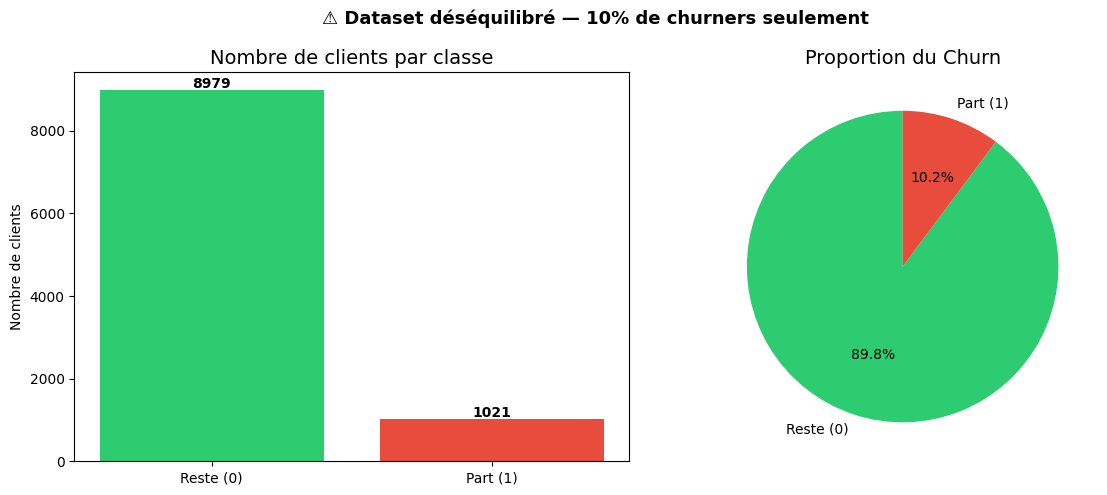

In [27]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graphique 1 — Barplot
axes[0].bar(['Reste (0)', 'Part (1)'], 
            churn_counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Nombre de clients par classe', fontsize=14)
axes[0].set_ylabel('Nombre de clients')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Graphique 2 — Camembert
axes[1].pie(churn_counts.values,
            labels=['Reste (0)', 'Part (1)'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Proportion du Churn', fontsize=14)

plt.suptitle('⚠️ Dataset déséquilibré — 10% de churners seulement', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Analyse du Revenu à Risque

Maintenant qu'on sait que 10.2% des clients churnent, on cherche à quantifier l'impact financier pour l'entreprise.

**Résultats :**
- Revenu moyen des clients qui restent : **1081€**
- Revenu moyen des clients qui partent : **845€**

Les clients qui partent ont un revenu moyen **plus faible** que  eux qui restent. Cela s'explique par le fait que les nouveaux clients (tenure bas) ont moins payé au total et sont aussi 
plus susceptibles de partir.

**Revenu total à risque : 862 640€** 

C'est le montant total que l'entreprise risque de perdre si tous les clients identifiés comme churners partent.

C'est directement lié à notre **Problématique 2** :
`revenue_at_risk = total_revenue × proba_churn`

Ce chiffre justifie l'importance de construire un modèle de prédiction performant — chaque churner non détecté  représente en moyenne **845€ de revenu perdu**.

In [28]:

# ANALYSE DU REVENU À RISQUE

# Revenu moyen par groupe churn

# Divise le dataset en 2 groupes, Groupe 0 : clients qui restent, Groupe 1 : clients qui partent,
revenu_par_churn = df.groupby('churn')['total_revenue'].mean() 

print(" Revenu moyen :")
print(f"  Clients qui restent  (0) : {revenu_par_churn[0]:.0f}€") #Accède à la moyenne des churn=0
print(f"  Clients qui partent  (1) : {revenu_par_churn[1]:.0f}€") #Accède à la moyenne des churn=1


# Revenu total à risque estimé
revenu_total_risque = df[df['churn'] == 1]['total_revenue'].sum()
print(f"\n Revenu total à risque : {revenu_total_risque:,}€")
#Formate le nombre :.0f = 0 décimales Exemple : 1083.456 → 1083

 Revenu moyen :
  Clients qui restent  (0) : 1081€
  Clients qui partent  (1) : 845€

 Revenu total à risque : 862,640€


## Distribution des variables numériques

On visualise la distribution de chaque variable numérique pour comprendre leur forme et détecter des anomalies.

Observations :
- `age`, `tenure_months` : distributions uniformes 
- `payment_failures`, `support_tickets` : majorité à 0 
  (normal, peu de clients ont des problèmes)
- `monthly_fee` : pics à 20€, 30€, 50€, 100€ 
  (ce sont des paliers tarifaires)
- `total_revenue` : très étalé, quelques gros clients
- `nps_score` : distribution large de -100 à +100
- `last_login_days_ago` : pic à 0, queue jusqu'à 80 jours

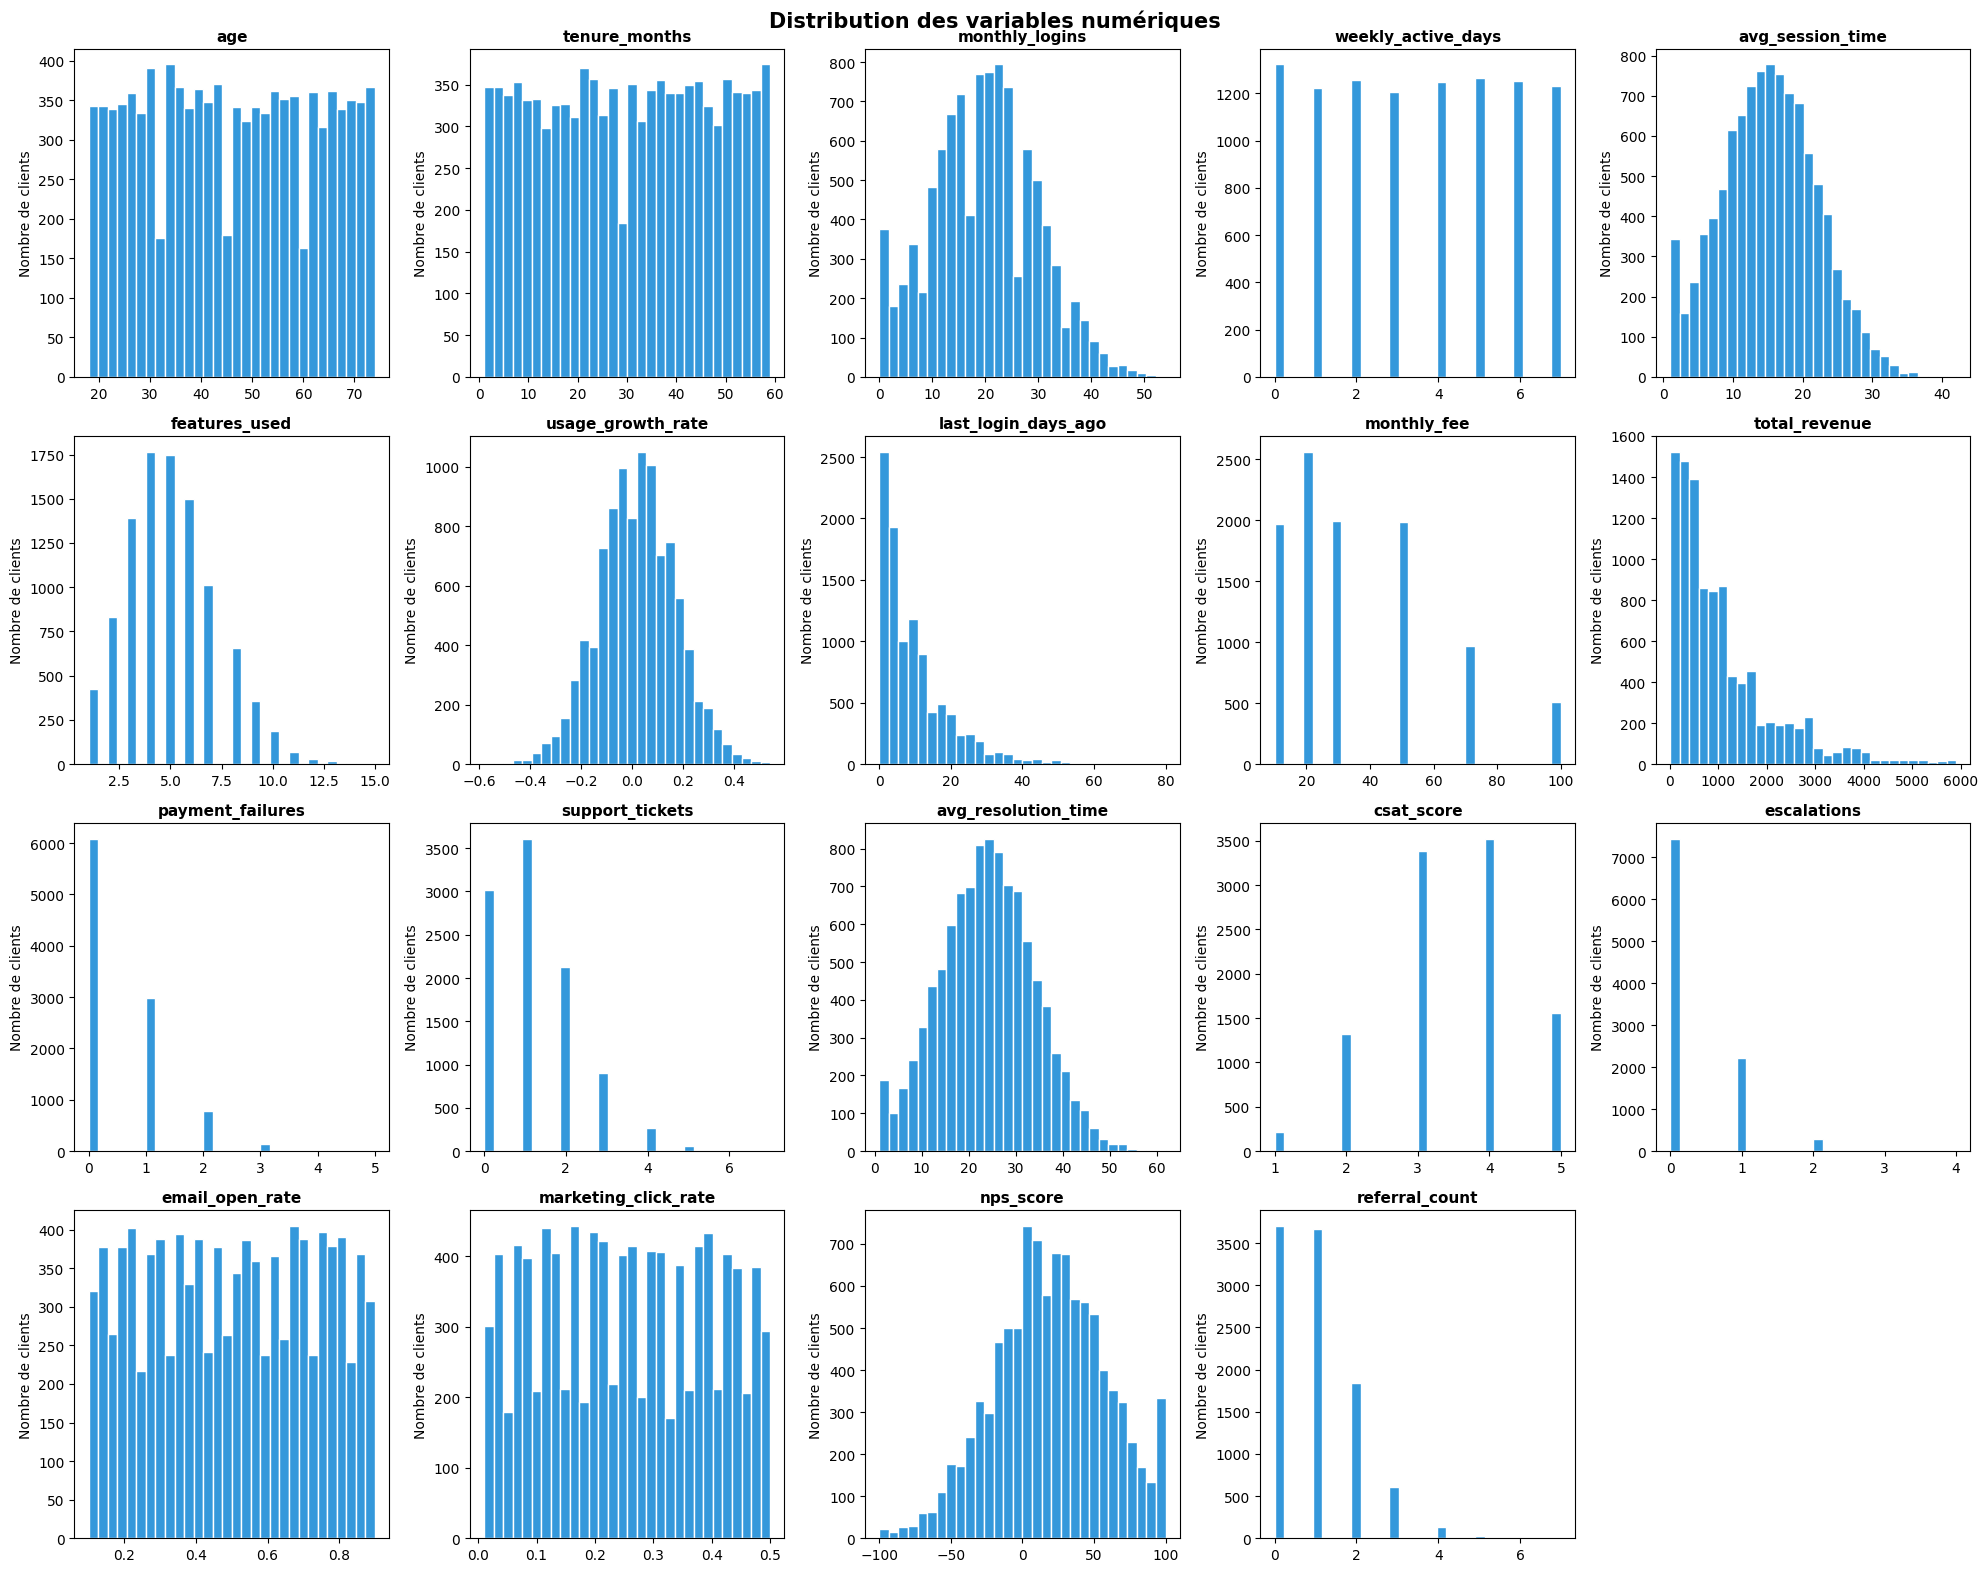

In [29]:

# Liste des colonnes numériques (sans churn)
cols_numeriques = ['age', 'tenure_months', 'monthly_logins', 
                   'weekly_active_days', 'avg_session_time',
                   'features_used', 'usage_growth_rate',
                   'last_login_days_ago', 'monthly_fee', 
                   'total_revenue', 'payment_failures',
                   'support_tickets', 'avg_resolution_time',
                   'csat_score', 'escalations', 'email_open_rate',
                   'marketing_click_rate', 'nps_score', 'referral_count']

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(cols_numeriques):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Nombre de clients')

# Supprimer les cases vides
for j in range(len(cols_numeriques), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution des variables numériques', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Distribution des variables catégorielles

On analyse les 10 variables textuelles du dataset.

Observations :
- `gender` : parfaitement équilibré (50/50) 
- `country` : 7 pays, très équilibrés (~1400 chacun) 
- `customer_segment` : Individual (60%) > SME (30%) > Enterprise (10%)
- `contract_type` : Monthly dominant (50%)
- `payment_method` : Card dominant (60%)
- `discount_applied` : 30% des clients ont une remise
- `price_increase_last_3m` : 19% ont subi une hausse de prix
- `complaint_type` : Technical > Billing > Service
- `survey_response` : 50% satisfaits, 20% insatisfaits

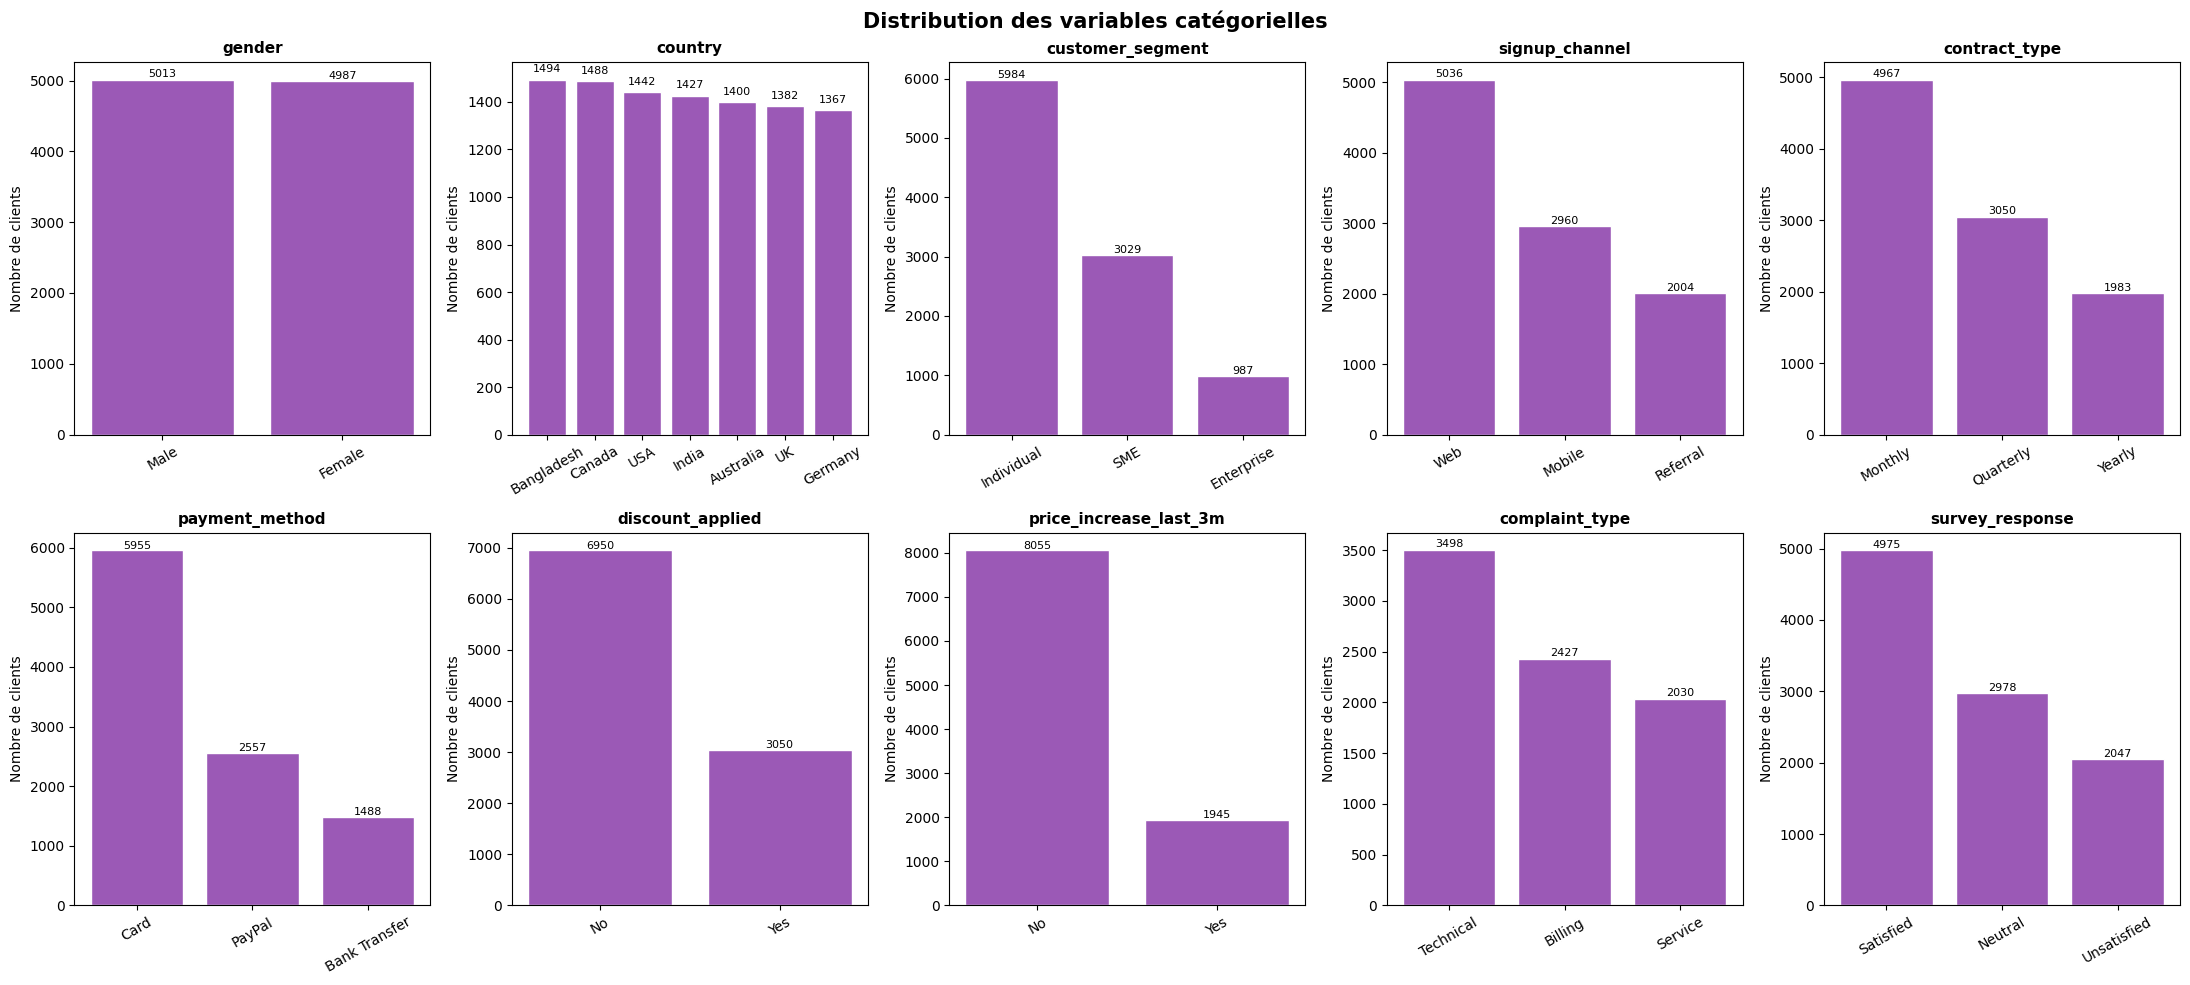

In [30]:
# DISTRIBUTION DES VARIABLES CATÉGORIELLES

cols_cat = ['gender', 'country', 'customer_segment', 
            'signup_channel', 'contract_type', 
            'payment_method', 'discount_applied',
            'price_increase_last_3m', 'complaint_type',
            'survey_response']

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(cols_cat):
    # Compter les valeurs
    counts = df[col].value_counts()
    
    axes[i].bar(counts.index, counts.values, color='#9b59b6', edgecolor='white')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Nombre de clients')
    axes[i].tick_params(axis='x', rotation=30)
    
    # Afficher les valeurs sur les barres
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 30, str(v), ha='center', fontsize=8)

plt.suptitle('Distribution des variables catégorielles', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Taux de churn par variable catégorielle

On calcule le taux de churn moyen pour chaque modalité. La ligne pointillée = moyenne globale (10.2%).

Insights majeurs :
- `customer_segment` SME : **30.9% de churn** 
  Les petites entreprises sont 3x plus à risque que les particuliers
- `signup_channel` Mobile : **30%** 
  Les clients acquis via mobile partent beaucoup plus
- `price_increase_last_3m` Yes : **30.4%** 
  Une hausse de prix récente = signal fort de départ
- `country` Australia : **11.5%** légèrement au-dessus
- `survey_response` Unsatisfied : **11.1%** légèrement au-dessus

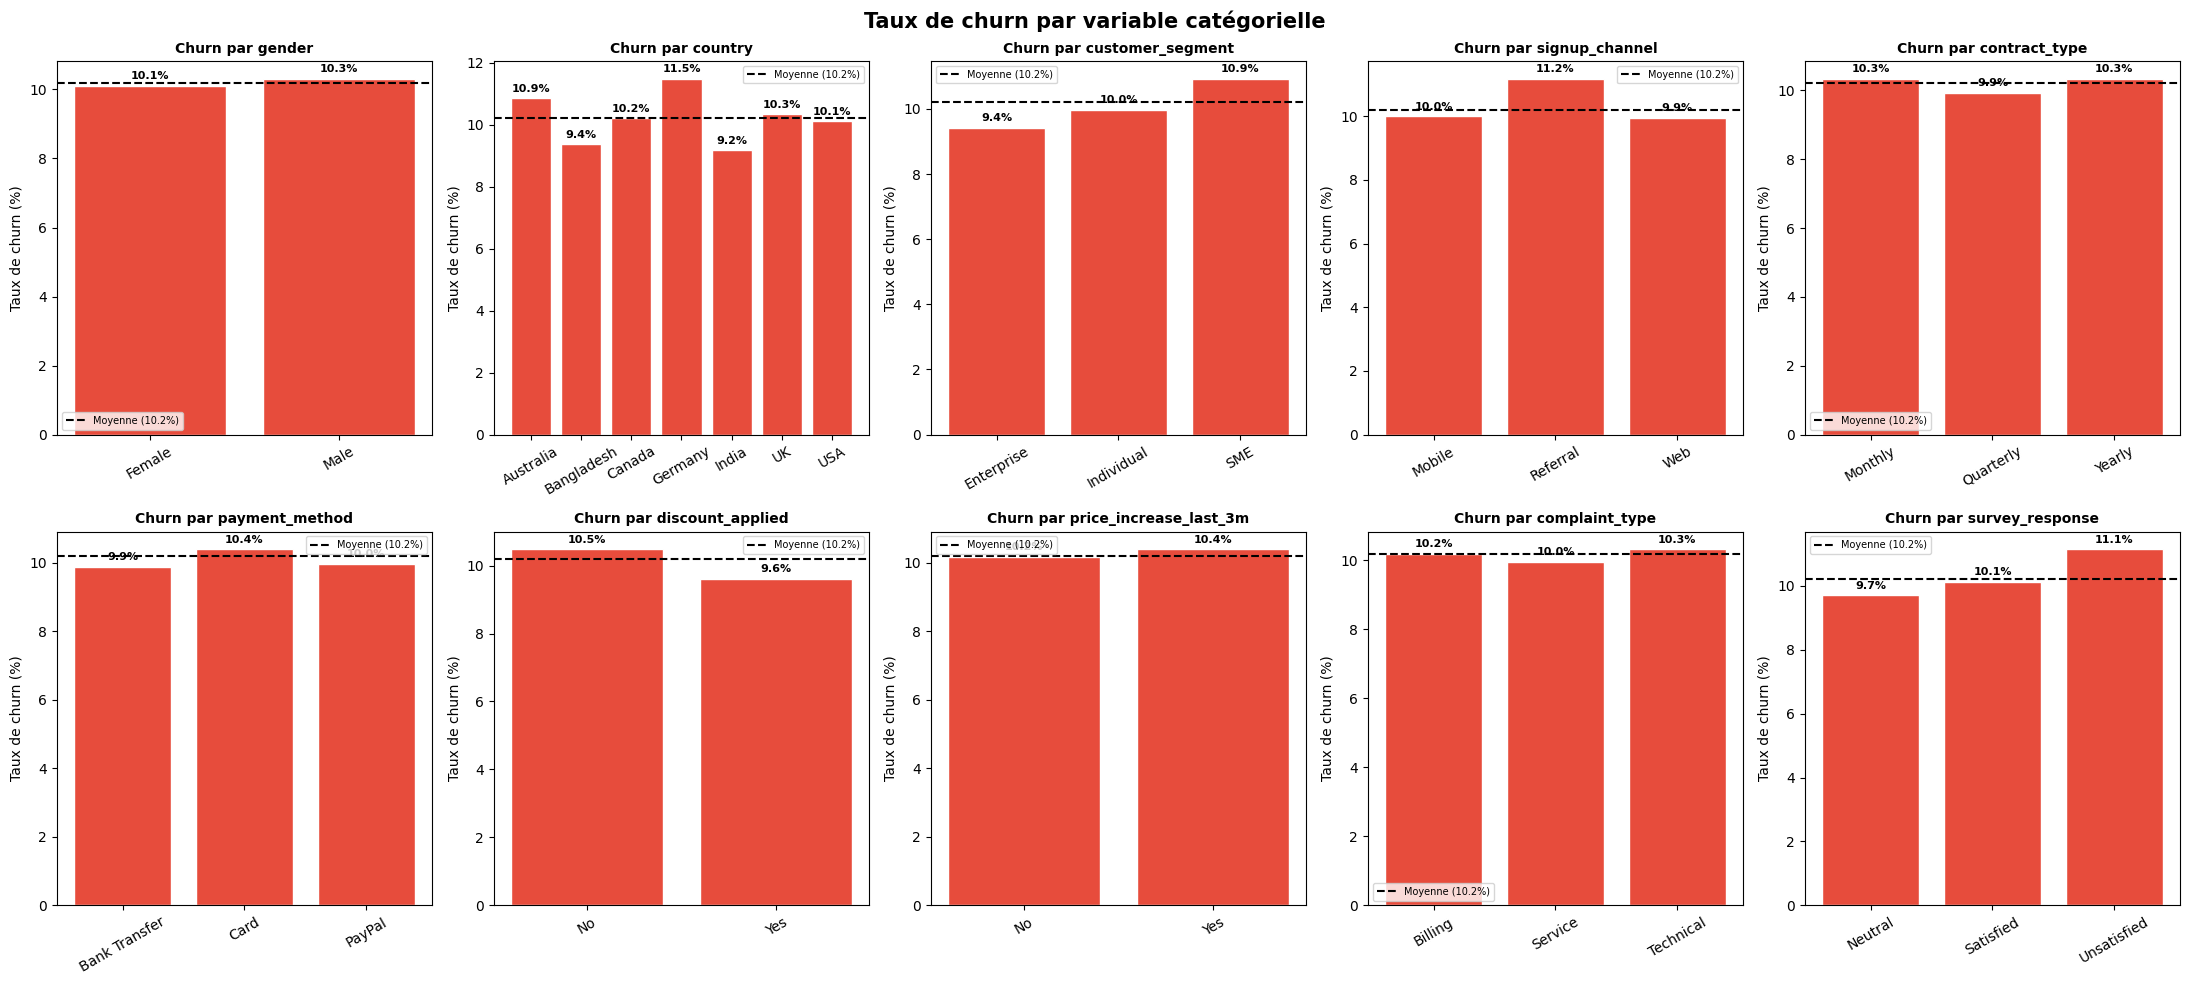

In [31]:
# CHURN PAR VARIABLE CATÉGORIELLE

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(cols_cat):
    # Taux de churn moyen par catégorie
    churn_rate = df.groupby(col)['churn'].mean() * 100
    
    bars = axes[i].bar(churn_rate.index, 
                       churn_rate.values,
                       color='#e74c3c', 
                       edgecolor='white')
    axes[i].set_title(f'Churn par {col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Taux de churn (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(y=10.2, color='black', linestyle='--', 
                    label='Moyenne (10.2%)')
    axes[i].legend(fontsize=7)
    
    # Afficher les % sur les barres
    for j, v in enumerate(churn_rate.values):
        axes[i].text(j, v + 0.2, f'{v:.1f}%', 
                    ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Taux de churn par variable catégorielle', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Distribution des variables numériques selon le churn

On superpose les distributions des clients qui restent (vert) 
et des clients qui partent (rouge) pour chaque variable.

Insights clés :
- `tenure_months` : les churners sont concentrés au début (0-5 mois)
  → Les nouveaux clients partent plus facilement
- `payment_failures` : les churners ont plus d'échecs de paiement
  → Signal fort de risque de churn
- `support_tickets` : les churners ouvrent plus de tickets
  → La frustration mène au départ
- `nps_score` : les churners ont un NPS plus bas
  → Un client insatisfait est un client à risque
- `last_login_days_ago` : les churners se connectent moins
  → Le désengagement précède le départ
- `csat_score` : les churners ont un score de 2 principalement
  → Satisfaction basse = départ

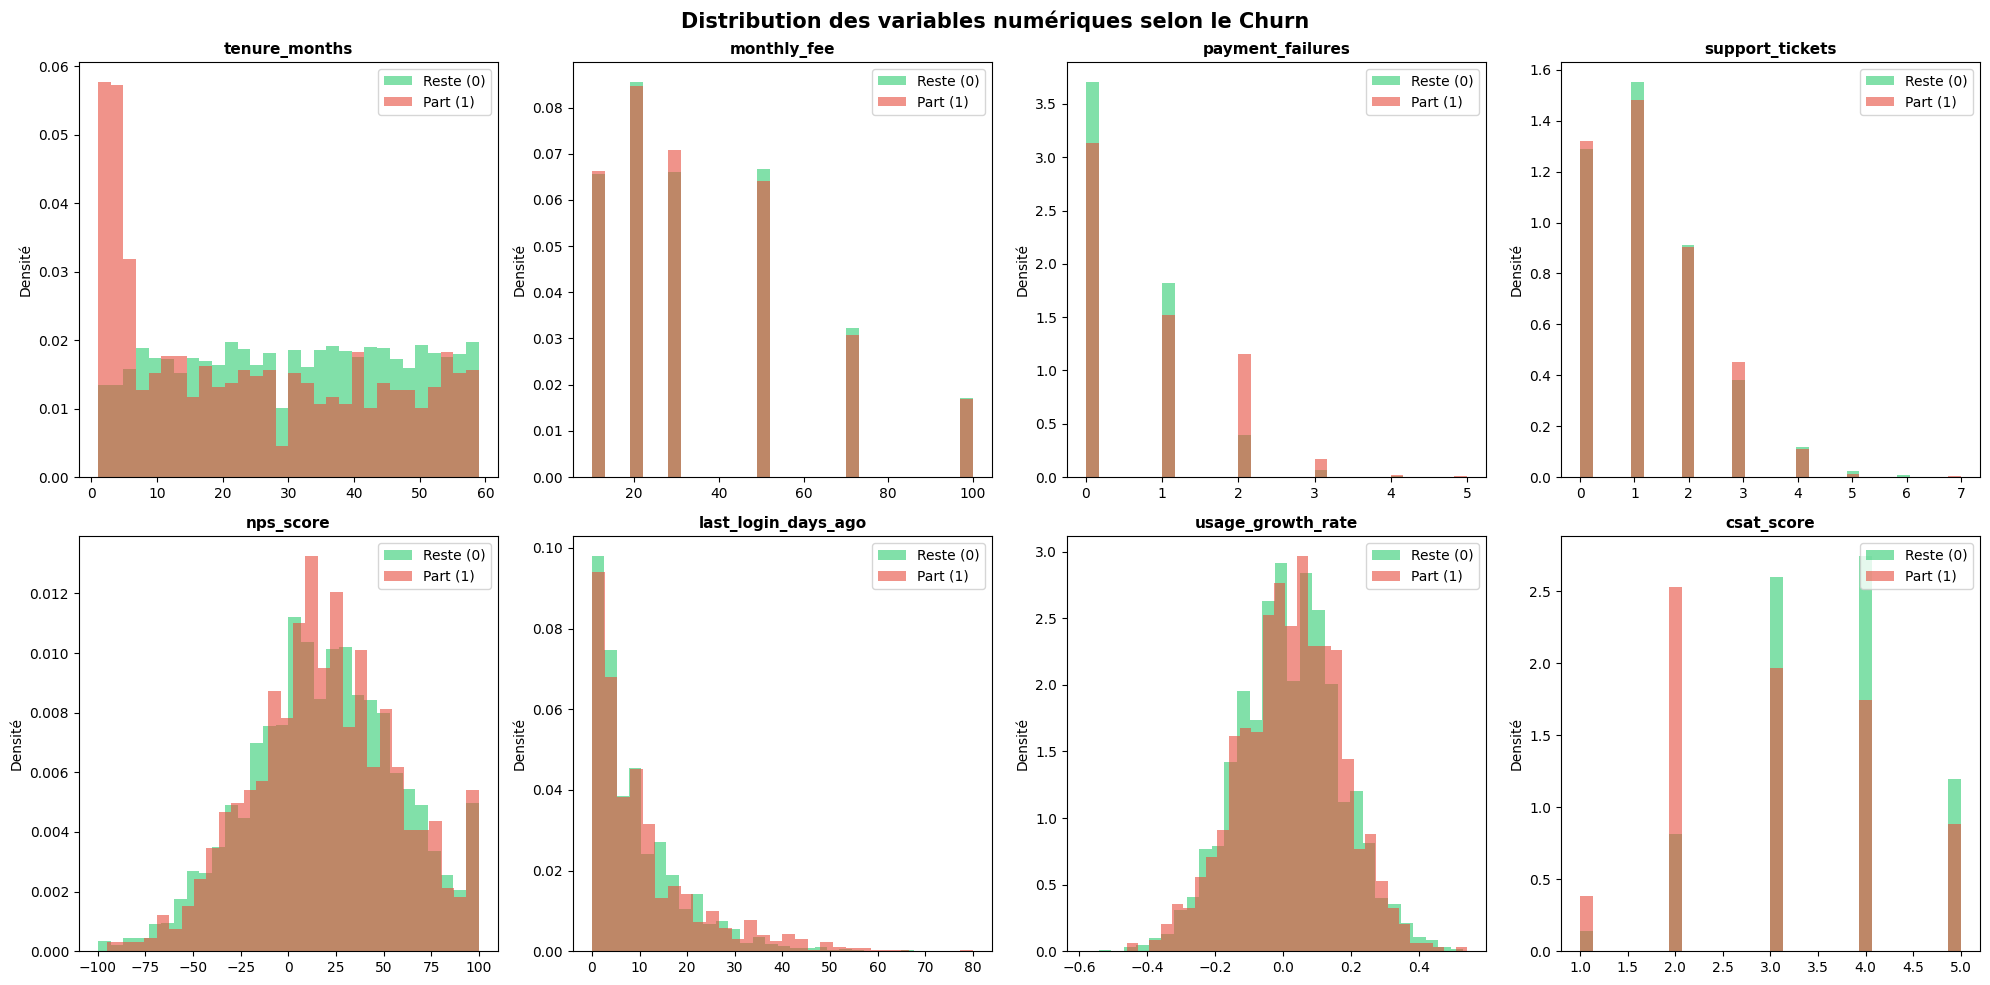

In [32]:

# CHURN PAR VARIABLE NUMÉRIQUE

cols_num_importantes = ['tenure_months', 'monthly_fee', 
                        'payment_failures', 'support_tickets',
                        'nps_score', 'last_login_days_ago',
                        'usage_growth_rate', 'csat_score']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cols_num_importantes):
    # Clients qui restent vs qui partent
    reste = df[df['churn'] == 0][col]
    part = df[df['churn'] == 1][col]
    
    axes[i].hist(reste, bins=30, alpha=0.6, 
                 color='#2ecc71', label='Reste (0)', density=True)
    axes[i].hist(part, bins=30, alpha=0.6, 
                 color='#e74c3c', label='Part (1)', density=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Densité')
    axes[i].legend()

plt.suptitle('Distribution des variables numériques selon le Churn', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Matrice de corrélation

La heatmap montre les corrélations entre toutes les variables 
numériques. Une corrélation va de -1 à +1 :
- **+1** : quand une variable augmente, l'autre aussi
- **-1** : quand une variable augmente, l'autre diminue
- **0** : aucun lien entre les deux variables

Corrélations avec le churn :
- `csat_score` : **-0.16** → satisfaction basse = plus de churn
- `tenure_months` : **-0.12** → ancienneté haute = moins de churn
- `payment_failures` : **+0.11** → échecs = plus de churn

Corrélations entre variables :
- `monthly_fee` ↔ `total_revenue` : **+0.71** 
  Ces deux variables sont très liées → attention à la redondance
- `tenure_months` ↔ `total_revenue` : **+0.59**
  Logique : plus on est ancien, plus on a payé au total

Les corrélations faibles avec le churn confirment que le Machine 
Learning est nécessaire — le churn dépend de combinaisons 
complexes de variables, pas d'une seule.

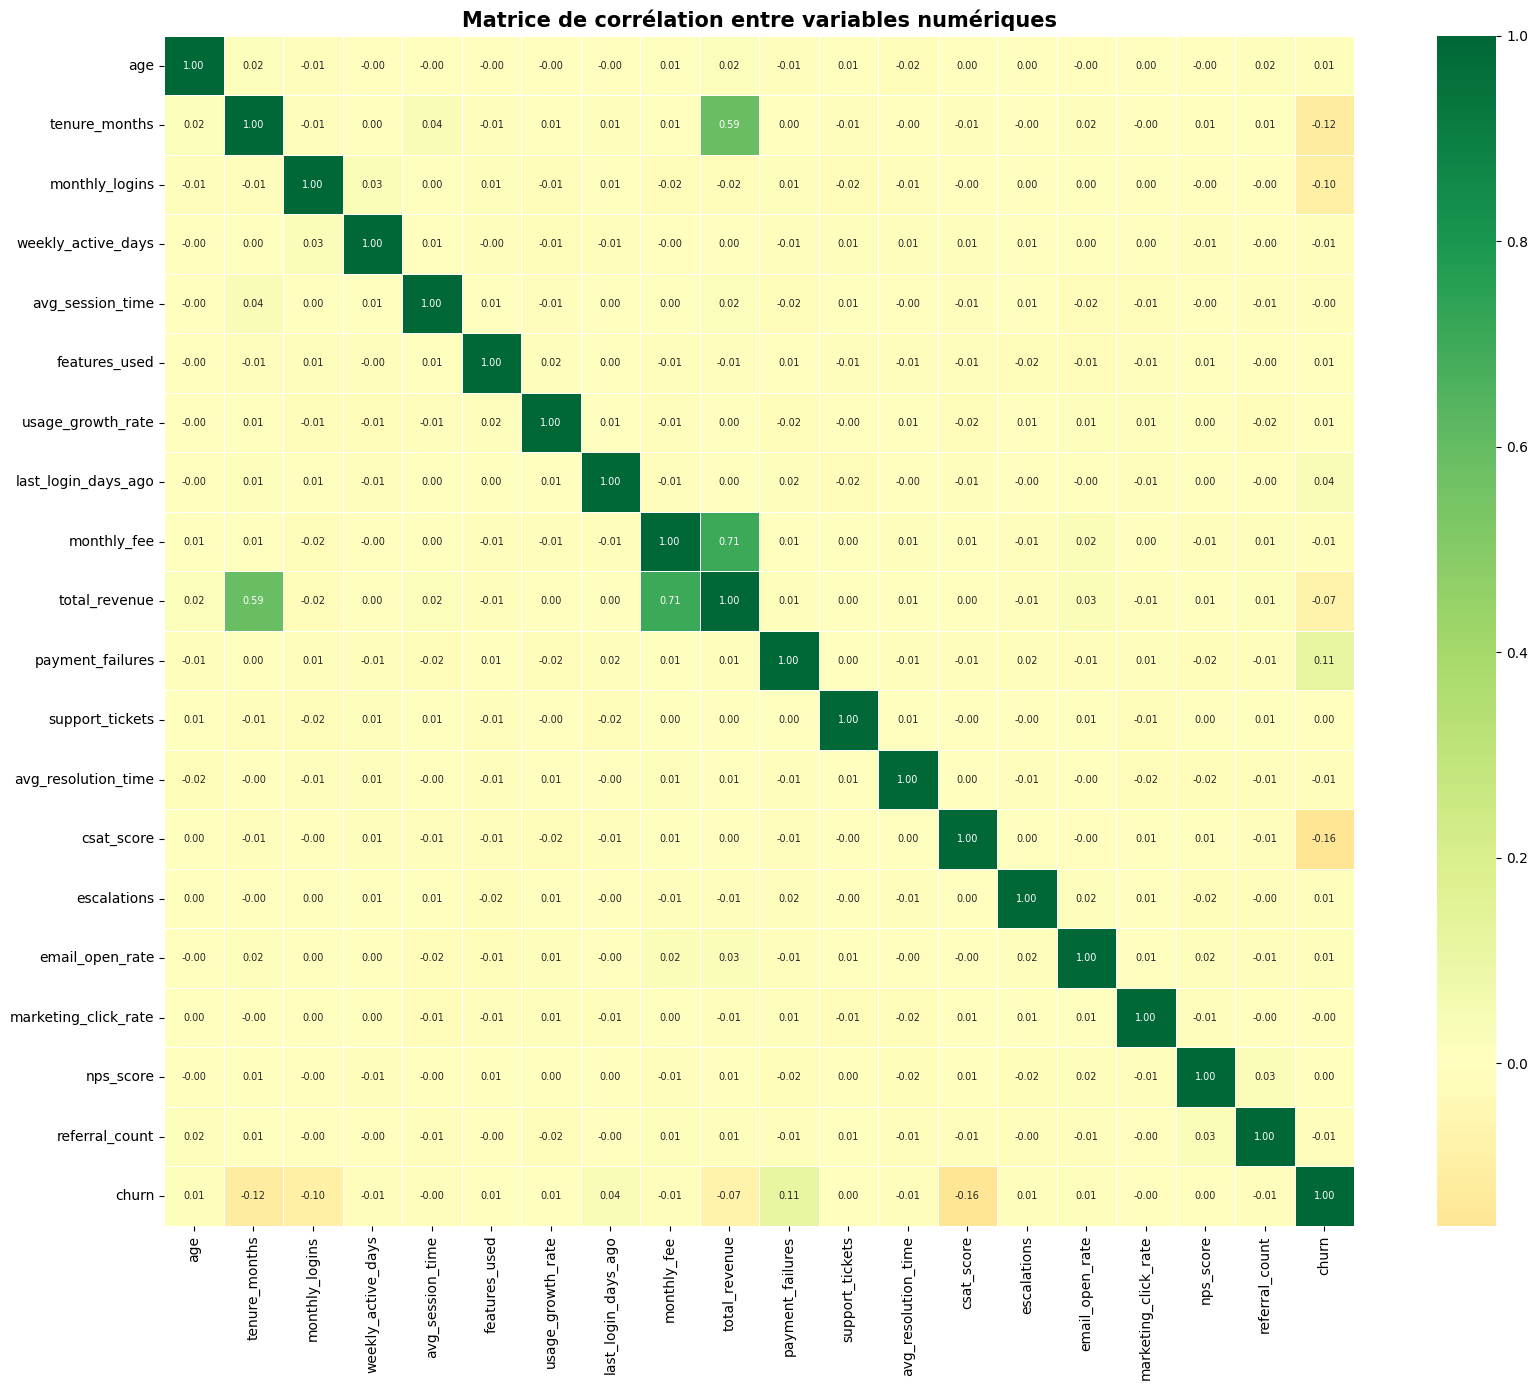

In [33]:

# HEATMAP DES CORRÉLATIONS

# Sélectionner uniquement les colonnes numériques
cols_corr = ['age', 'tenure_months', 'monthly_logins',
             'weekly_active_days', 'avg_session_time',
             'features_used', 'usage_growth_rate',
             'last_login_days_ago', 'monthly_fee',
             'total_revenue', 'payment_failures',
             'support_tickets', 'avg_resolution_time',
             'csat_score', 'escalations', 'email_open_rate',
             'marketing_click_rate', 'nps_score', 
             'referral_count', 'churn']

# Calculer la matrice de corrélation
corr_matrix = df[cols_corr].corr()

# Visualisation
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix,
            annot=True,           # afficher les valeurs
            fmt='.2f',            # 2 décimales
            cmap='RdYlGn',        # rouge = négatif, vert = positif
            center=0,             # centré sur 0
            square=True,
            linewidths=0.5,
            annot_kws={'size': 7})

plt.title('Matrice de corrélation entre variables numériques', 
          fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Détection des outliers — Boxplots

Un boxplot montre la distribution d'une variable :
- La boîte = 50% des données (entre 25% et 75%)
- La ligne noire = médiane (valeur du milieu)
- Les cercles = outliers (valeurs extrêmes)

Observations :
- `total_revenue` : outliers jusqu'à 5900€ → gros clients réels 
- `last_login_days_ago` : outliers jusqu'à 80 jours → inactifs 
- `payment_failures` : outliers à 4-5 → très mauvais payeurs 
- `nps_score` : outliers à -100 → clients très insatisfaits 
- `tenure_months` : churners ont une médiane plus basse → confirmé

**Décision : on garde tous les outliers.**
Ce ne sont pas des erreurs — ce sont des signaux business réels 
et importants pour prédire le churn.

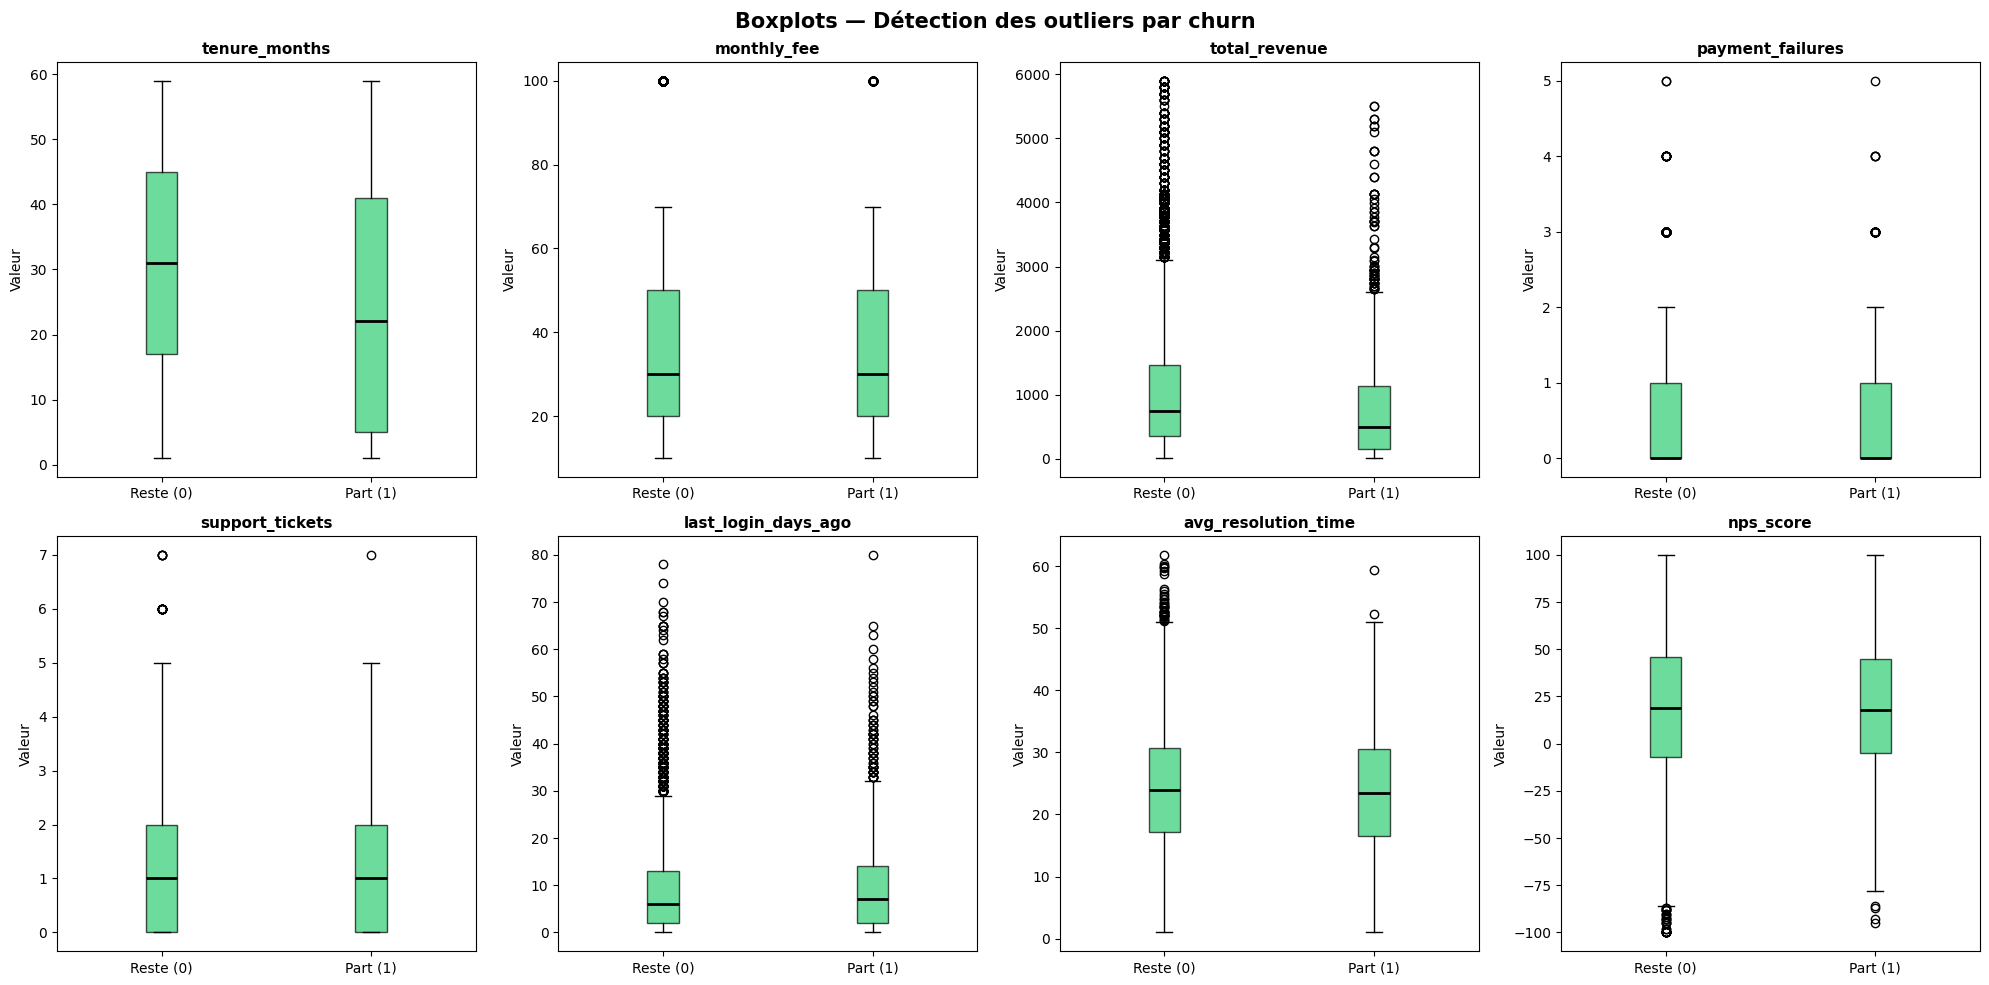

In [34]:

# DÉTECTION DES OUTLIERS
cols_outliers = ['tenure_months', 'monthly_fee', 'total_revenue',
                 'payment_failures', 'support_tickets',
                 'last_login_days_ago', 'avg_resolution_time',
                 'nps_score']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cols_outliers):
    data_reste = df[df['churn'] == 0][col]
    data_part = df[df['churn'] == 1][col]
    
    axes[i].boxplot([data_reste, data_part],
                    tick_labels=['Reste (0)', 'Part (1)'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#2ecc71', alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Valeur')

plt.suptitle('Boxplots — Détection des outliers par churn',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()  # ← juste ça !

# Synthèse de l'EDA

## Ce qu'on a découvert
1. **Déséquilibre** : 89.8% restent vs 10.2% partent
2. **Nouveaux clients** à risque : tenure_months bas = plus de churn
3. **Signaux forts** : payment_failures, csat_score, support_tickets
4. **Segments à risque** : SME (30.9%), Mobile (30%), hausse prix (30.4%)
5. **Corrélation forte** : monthly_fee ↔ total_revenue (0.71)
6. **Valeurs manquantes** : complaint_type (2045) → "No_Complaint"
7. **Outliers** : conservés car signaux business réels

## Décisions pour le Preprocessing (étape suivante)
1. Supprimer `customer_id` et `city` (inutiles pour la prédiction)
2. Remplir `complaint_type` manquants par "No_Complaint"
3. Encoder les 12 variables catégorielles en chiffres
4. Normaliser les variables numériques (StandardScaler)
5. Gérer le déséquilibre avec `class_weight='balanced'`
6. Séparer Train (80%) / Test (20%) de façon stratifiée